# Statistisk evaluering: Haiku vs Opus på eksamensopgaver
**Kursus 02445** — samlet analyse-notebook.

## Sådan er datasættet bygget — og hvad det betyder for statistikken
Vi har **54 distinkte spørgsmål** (2 eksamenssæt à 27). Hvert spørgsmål er besvaret
**5 gange** af hver model; datasættet gemmer pr. spørgsmål *antal korrekte ud af 5*
(`* True`) og *antal forkerte* (`* False`).

**Den statistiske enhed er spørgsmålet (n = 54), ikke de 5·54 = 270 enkeltsvar.**
De 5 gentagelser af samme spørgsmål er ikke indbyrdes uafhængige, så at behandle dem
som 270 selvstændige observationer er pseudoreplikation. Hele denne notebook kører
derfor på spørgsmål-niveau.

To komplementære spor, begge med n = 54:
1. **Binært spor** — flertalsafstemning (≥3/5) → Jeffrey-CI + **McNemar** + agreement-matrix.
2. **Kontinuert spor** — accuracy pr. spørgsmål → **Wilcoxon signed-rank** + boxplot.

In [17]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

alpha = 0.05
REPS  = 5

## 1. Indlæs og rens data
Robust over for `Haiko`/`Haiku`-stavningen og stavefejlen `Knowlegde`.

In [18]:
# Ret stien til hvor datafilen ligger relativt til notebooken
DATA_PATH = "Dataset.csv"

df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8-sig")
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]      # fjern tomme kolonner
df.columns = df.columns.str.strip()                         # trim kolonnenavne
df = df.rename(columns={"Haiko True": "Haiku True",         # ensret stavning
                        "Haiko False": "Haiku False"})
df["Q_Type"] = df["Q_Type"].str.strip().replace({"Knowlegde": "Knowledge"})
df

,Examset,Question,Q_Type,Haiku True,Haiku False,Opus True,Opus False
0,Spring 2025,1,Visual,5,0,5,0
1,Spring 2025,2,Visual,0,5,5,0
2,Spring 2025,3,Computational,0,5,5,0
3,Spring 2025,4,Visual,4,1,4,1
4,Spring 2025,5,Knowledge,0,5,5,0
5,Spring 2025,6,Computational,1,4,5,0
6,Spring 2025,7,Computational,0,5,5,0
7,Spring 2025,8,Computational,0,5,5,0
8,Spring 2025,9,Visual,0,5,5,0
9,Spring 2025,10,Computational,0,5,1,4


## 2. Sanity checks
Bekræft at vi har 54 spørgsmål, og at hvert spørgsmål har præcis 5 gentagelser pr. model.

In [19]:
assert len(df) == 54, f"Forventede 54 spørgsmål, fik {len(df)}"
ok_h = (df["Haiku True"] + df["Haiku False"] == REPS).all()
ok_o = (df["Opus True"]  + df["Opus False"]  == REPS).all()
print("54 spørgsmål:", len(df) == 54)
print("5 gentagelser pr. spørgsmål (Haiku/Opus):", bool(ok_h), bool(ok_o))
print("\nSpørgsmål pr. type:\n", df["Q_Type"].value_counts().to_string())
print("\nSpørgsmål pr. eksamenssæt:\n", df["Examset"].value_counts().to_string())

54 spørgsmål: True
5 gentagelser pr. spørgsmål (Haiku/Opus): True True

Spørgsmål pr. type:
 Q_Type
Visual           27
Computational    17
Knowledge        10

Spørgsmål pr. eksamenssæt:
 Examset
Spring 2025    27
Fall 2025      27


## 3. Deskriptiv accuracy (samlet og pr. spørgsmålstype)
Her bruger vi den gennemsnitlige accuracy (andel korrekte ud af 5, midlet over spørgsmål).
Per type er dette identisk med "antal korrekte svar / (antal spørgsmål · 5)". Rent beskrivende.
Subgrupperne (10–27 spørgsmål) er for små til selvstændige hypotesetests.

ACCURACY BY QUESTION TYPE (deskriptivt)

Overall:
  Haiku: 44.1%
  Opus:  85.6%
  Diff:  +41.5%

Computational:
  Haiku: 22.4%
  Opus:  95.3%
  Diff:  +72.9%

Knowledge:
  Haiku: 60.0%
  Opus:  92.0%
  Diff:  +32.0%

Visual:
  Haiku: 51.9%
  Opus:  77.0%
  Diff:  +25.2%


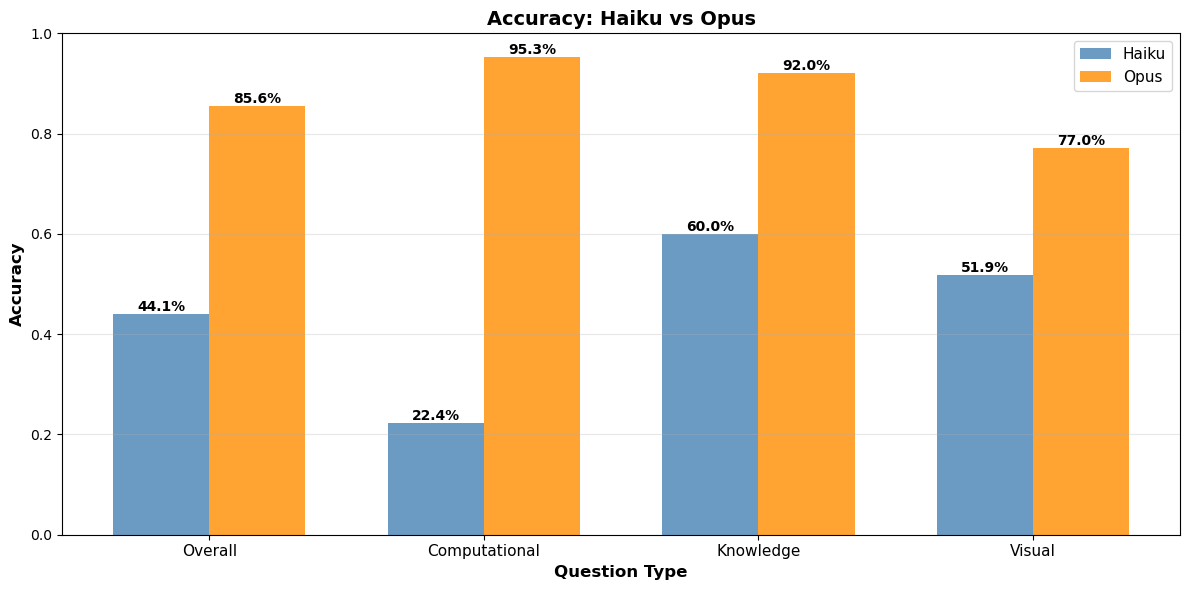

In [20]:
df["Haiku_acc"] = df["Haiku True"] / REPS
df["Opus_acc"]  = df["Opus True"]  / REPS

results = {"Overall": [df["Haiku_acc"].mean(), df["Opus_acc"].mean()]}
for qtype in sorted(df["Q_Type"].unique()):
    sub = df[df["Q_Type"] == qtype]
    results[qtype] = [sub["Haiku_acc"].mean(), sub["Opus_acc"].mean()]

print("=" * 60); print("ACCURACY BY QUESTION TYPE (deskriptivt)"); print("=" * 60)
for qtype, accs in results.items():
    print(f"\n{qtype}:")
    print(f"  Haiku: {accs[0]:.1%}")
    print(f"  Opus:  {accs[1]:.1%}")
    print(f"  Diff:  {accs[1]-accs[0]:+.1%}")

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results)); width = 0.35
h_vals = [results[k][0] for k in results]; o_vals = [results[k][1] for k in results]
b1 = ax.bar(x - width/2, h_vals, width, label="Haiku", color="steelblue", alpha=0.8)
b2 = ax.bar(x + width/2, o_vals, width, label="Opus",  color="darkorange", alpha=0.8)
ax.set_ylabel("Accuracy", fontsize=12, fontweight="bold")
ax.set_xlabel("Question Type", fontsize=12, fontweight="bold")
ax.set_title("Accuracy: Haiku vs Opus", fontsize=14, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(results.keys(), fontsize=11)
ax.legend(fontsize=11); ax.set_ylim([0, 1]); ax.grid(True, alpha=0.3, axis="y")
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                f"{bar.get_height():.1%}", ha="center", va="bottom",
                fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

## 4. Pilotstudie: stikprøvestørrelse
Pilotens accuracies beregnes nu direkte fra pilotdatasættet (`final pilot.csv`, 27 spørgsmål).
**Bemærk fortolkningen:** med pilotens relativt lille forskel (~15 procentpoint) ville formlen
kræve ~149 spørgsmål pr. gruppe ved 80% styrke. Vi gennemførte med 54 af praktiske hensyn;
den *realiserede* forskel viste sig langt større (~43 pp), hvilket er grunden til at 54
spørgsmål alligevel gav overvældende signifikans (se nedenfor).
*(Kræver `final pilot.csv` i samme mappe.)*

In [21]:
# Load data
pilot_path = "final pilot.csv"
df_pilot_study = pd.read_csv(pilot_path, sep=";", encoding="utf-8-sig", skiprows=2)

# Rename columns
df_pilot_study.columns = ['ID', 'Semester', 'Question', 'Haiku_True', 'Haiku_False', 'Opus_True', 'Opus_False']

# Fill NaN with 0
df_pilot_study = df_pilot_study.fillna(0)

df_pilot_study

,ID,Semester,Question,Haiku_True,Haiku_False,Opus_True,Opus_False
0,2,Fall 2025,B,0.0,1.0,1.0,0.0
1,3,Fall 2025,A,1.0,0.0,1.0,0.0
2,4,Fall 2025,D,1.0,0.0,1.0,0.0
3,5,Fall 2025,C,1.0,0.0,1.0,0.0
4,6,Fall 2025,B,0.0,1.0,0.0,1.0
5,7,Fall 2025,A,1.0,0.0,1.0,0.0
6,8,Fall 2025,C,1.0,0.0,1.0,0.0
7,9,Fall 2025,B,1.0,0.0,1.0,0.0
8,10,Fall 2025,D,1.0,0.0,0.0,1.0
9,11,Fall 2025,A,0.0,1.0,1.0,0.0


In [22]:
# Calculate accuracy (simply count True values)
haiku_correct = df_pilot_study['Haiku_True'].sum()
opus_correct = df_pilot_study['Opus_True'].sum()

accuracy_haiku = haiku_correct / 27
accuracy_opus = opus_correct / 27

print(f"Haiku: {int(haiku_correct)}/27 = {accuracy_haiku:.1%}")
print(f"Opus:  {int(opus_correct)}/27 = {accuracy_opus:.1%}")

Haiku: 16/27 = 59.3%
Opus:  23/27 = 85.2%


In [23]:
p1 = accuracy_haiku
p2 = accuracy_opus
alfa = 0.05
power = 0.80 

z_alfa_2 = st.norm.ppf(0.975)
z_beta = st.norm.ppf(0.80)

accuracy_difference = abs(p2-p1)
P_mean = (0.6296 + 0.7778) / 2

n = ((z_alfa_2 + z_beta)**2) * 2 * P_mean * (1-P_mean) / (accuracy_difference**2)
n

np.float64(48.69544299225633)

## 5. Binarisering: flertalsafstemning (≥3/5)
For det binære spor reducerer vi hvert spørgsmål til ét udfald pr. model:
"løst" hvis modellen rammer rigtigt i flertallet af de 5 gentagelser.

In [24]:
df["Haiku_bin"] = (df["Haiku True"] > df["Haiku False"]).astype(int)
df["Opus_bin"]  = (df["Opus True"]  > df["Opus False"]).astype(int)
n = len(df)
print(f"Haiku løste {df['Haiku_bin'].sum()}/{n} spørgsmål")
print(f"Opus  løste {df['Opus_bin'].sum()}/{n} spørgsmål")

Haiku løste 23/54 spørgsmål
Opus  løste 46/54 spørgsmål


## 6. Accuracy pr. model med Jeffrey 95%-CI (n = 54)
Konfidensintervallet afspejler usikkerheden ved 54 spørgsmål — bredt for hver model hver for sig.

Model accuracy n = 54

Haiku:  theta = 0.427   CI = [0.301, 0.559]
Opus:   theta = 0.845   CI = [0.740, 0.927]


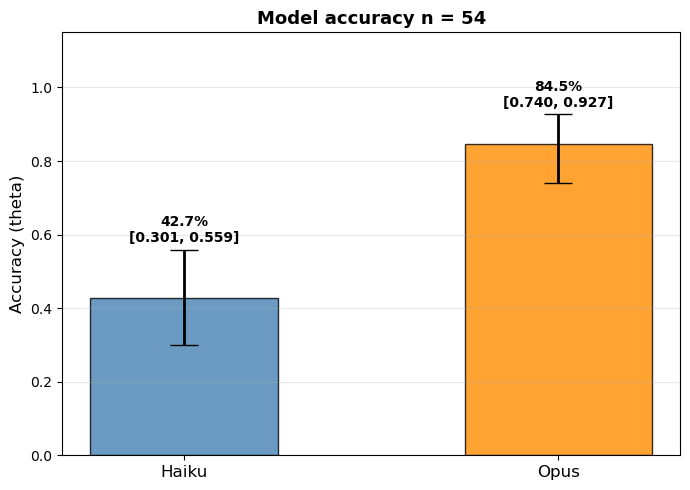

In [25]:
def jeffrey_interval(m, n, alpha=0.05):
    a, b = m + 0.5, n - m + 0.5
    return a / (a + b), st.beta.interval(1 - alpha, a, b)

m_h, m_o = df["Haiku_bin"].sum(), df["Opus_bin"].sum()
th_h, ci_h = jeffrey_interval(m_h, n)
th_o, ci_o = jeffrey_interval(m_o, n)
print("=" * 60); print("Model accuracy n = 54"); print("=" * 60)
print(f"\nHaiku:  theta = {th_h:.3f}   CI = [{ci_h[0]:.3f}, {ci_h[1]:.3f}]")
print(f"Opus:   theta = {th_o:.3f}   CI = [{ci_o[0]:.3f}, {ci_o[1]:.3f}]")

fig, ax = plt.subplots(figsize=(7, 5))
for i, (mdl, th, ci, c) in enumerate(zip(["Haiku","Opus"], [th_h,th_o],
                                         [ci_h,ci_o], ["steelblue","darkorange"])):
    ax.bar(i, th, color=c, alpha=0.8, edgecolor="black", width=0.5)
    ax.errorbar(i, th, yerr=[[th-ci[0]],[ci[1]-th]], fmt="none",
                color="black", capsize=10, linewidth=2)
    ax.text(i, ci[1]+0.02, f"{th:.1%}\n[{ci[0]:.3f}, {ci[1]:.3f}]",
            ha="center", fontsize=10, fontweight="bold")
ax.set_xticks([0,1]); ax.set_xticklabels(["Haiku","Opus"], fontsize=12)
ax.set_ylim([0,1.15]); ax.set_ylabel("Accuracy (theta)", fontsize=12)
ax.set_title("Model accuracy n = 54", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

## 7. McNemar's test (parret, n = 54) + agreement-matrix
Primær test for H0: p_Haiku = p_Opus. McNemar er den korrekte parrede test, fordi begge
modeller besvarer de samme spørgsmål. theta defineres som accuracy(Opus) − accuracy(Haiku).

McNEMAR TEST  —  n = 54

  Begge rigtige:        21
  Kun Opus rigtig:      25
  Kun Haiku rigtig:     2
  Begge forkerte:       6
  Uenige par (n12+n21): 27

  theta (Opus - Haiku): +0.426
  95% CI:               [0.271, 0.569]
  p-værdi:              5.65e-06

  SIGNIFIKANT  Opus bedre end Haiku


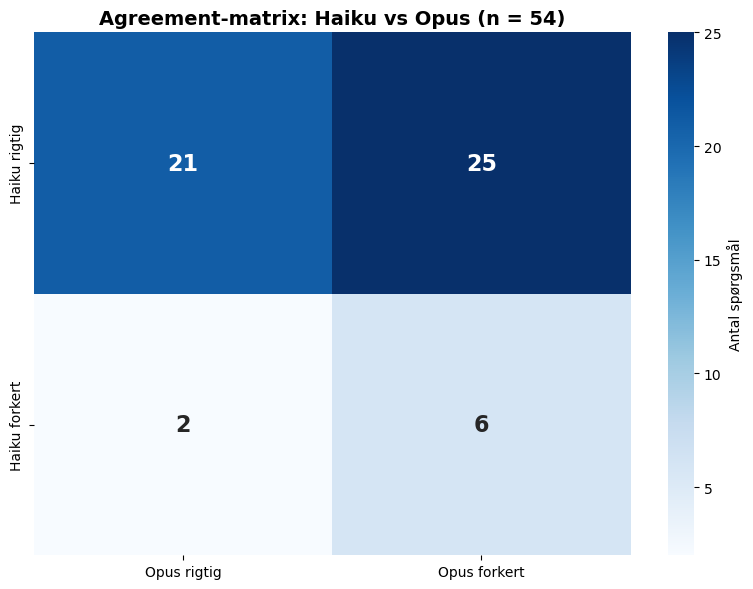

In [26]:
def mcnemar(yA, yB, alpha=0.05):
    """theta = acc(A) - acc(B). Kald med A=Opus, B=Haiku."""
    cA, cB = yA == 1, yB == 1
    n11 = int((cA &  cB).sum())   # begge rigtige
    n12 = int((cA & ~cB).sum())   # kun A (Opus) rigtig
    n21 = int((~cA & cB).sum())   # kun B (Haiku) rigtig
    n22 = int((~cA & ~cB).sum())  # begge forkerte
    N = len(yA); E = (n12 - n21) / N
    Q = (N**2 * (N+1) * (E+1) * (1-E)) / (N*(n12+n21) - (n12-n21)**2)
    f = (E+1)/2 * (Q-1); g = (1-E)/2 * (Q-1)
    CI = tuple(b*2 - 1 for b in st.beta.interval(1-alpha, a=f, b=g))
    p  = 2 * st.binom.cdf(min(n12, n21), n=n12+n21, p=0.5)
    return E, CI, p, (n11, n12, n21, n22)

E, CI_mc, p_mc, (n11, n12, n21, n22) = mcnemar(df["Opus_bin"].values, df["Haiku_bin"].values)
print("=" * 60); print("McNEMAR TEST  —  n = 54"); print("=" * 60)
print(f"\n  Begge rigtige:        {n11}")
print(f"  Kun Opus rigtig:      {n12}")
print(f"  Kun Haiku rigtig:     {n21}")
print(f"  Begge forkerte:       {n22}")
print(f"  Uenige par (n12+n21): {n12 + n21}")
print(f"\n  theta (Opus - Haiku): {E:+.3f}")
print(f"  95% CI:               [{CI_mc[0]:.3f}, {CI_mc[1]:.3f}]")
print(f"  p-værdi:              {p_mc:.2e}")
print("\n  SIGNIFIKANT  Opus bedre end Haiku" if p_mc < alpha
      else f"\n  IKKE signifikant (p >= {alpha})")
print("=" * 60)

matrix = np.array([[n11, n12], [n21, n22]])
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Opus rigtig","Opus forkert"],
            yticklabels=["Haiku rigtig","Haiku forkert"],
            cbar_kws={"label":"Antal spørgsmål"}, annot_kws={"size":16,"weight":"bold"})
ax.set_title("Agreement-matrix: Haiku vs Opus (n = 54)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

### 7b. McNemar: fordeling af θ
Visualisering af samme test — posteriorfordelingen af θ med 95%-CI og nulhypotesen θ = 0.

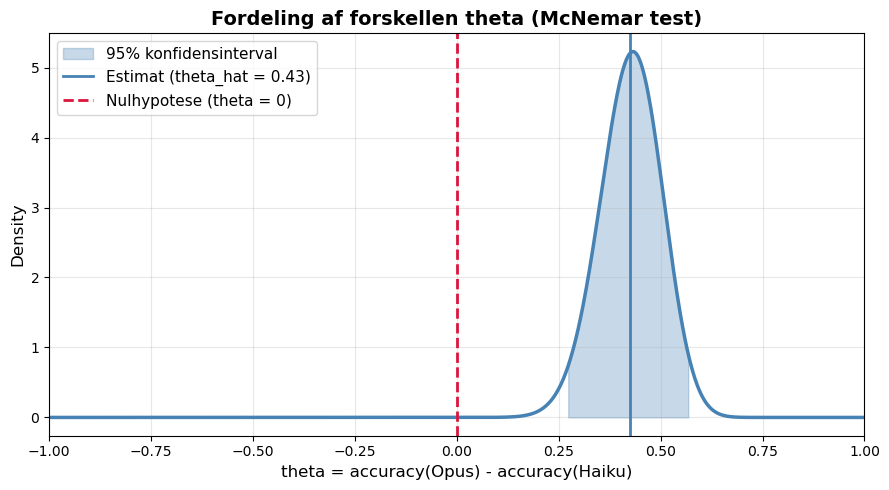

In [27]:
# Fordeling af theta (samme McNemar-test som ovenfor, visualiseret). Fortegn: Opus - Haiku.
N = len(df)
E_plot = (n12 - n21) / N
Q_plot = N**2 * (N + 1) * (E_plot + 1) * (1 - E_plot) / (N * (n12 + n21) - (n12 - n21)**2)
f_plot = (E_plot + 1) / 2 * (Q_plot - 1)
g_plot = (1 - E_plot) / 2 * (Q_plot - 1)

theta = np.linspace(-1, 1, 1000)
density = 0.5 * st.beta.pdf((theta + 1) / 2, a=f_plot, b=g_plot)

plt.figure(figsize=(9, 5))
plt.plot(theta, density, color="steelblue", linewidth=2.5)
inside = (theta >= CI_mc[0]) & (theta <= CI_mc[1])
plt.fill_between(theta[inside], density[inside], color="steelblue", alpha=0.3,
                 label="95% konfidensinterval")
plt.axvline(E, color="steelblue", linewidth=2, label=f"Estimat (theta_hat = {E:.2f})")
plt.axvline(0, color="crimson", linestyle="--", linewidth=2, label="Nulhypotese (theta = 0)")
plt.xlabel("theta = accuracy(Opus) - accuracy(Haiku)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Fordeling af forskellen theta (McNemar test)", fontsize=14, fontweight="bold")
plt.legend(fontsize=11); plt.grid(alpha=0.3); plt.margins(x=0)
plt.tight_layout(); plt.show()

## 8. Wilcoxon signed-rank (kontinuert spor, n = 54)
Komplementerer McNemar ved at bruge hele informationen i de 5 gentagelser. Ikke-parametrisk.

In [28]:
diff = df["Opus_acc"] - df["Haiku_acc"]      # positiv = Opus bedre
res = st.wilcoxon(df["Opus_acc"], df["Haiku_acc"], zero_method="wilcox", alternative="two-sided")
d = diff[diff != 0].to_numpy(); ranks = st.rankdata(np.abs(d))
rbc = (ranks[d > 0].sum() - ranks[d < 0].sum()) / ranks.sum()
print("=" * 60); print("WILCOXON SIGNED-RANK  —  n = 54"); print("=" * 60)
print(f"\n  Ikke-uafgjorte par:   {int((diff != 0).sum())}")
print(f"  W-statistik:          {res.statistic:.1f}")
print(f"  p-værdi:              {res.pvalue:.2e}")
print(f"  Median forskel (O-H): {np.median(diff):+.3f}")
print(f"  Middel forskel (O-H): {diff.mean():+.3f}")
print(f"  Rank-biserial r:      {rbc:.3f}")
print("=" * 60)

WILCOXON SIGNED-RANK  —  n = 54

  Ikke-uafgjorte par:   36
  W-statistik:          51.0
  p-værdi:              6.40e-06
  Median forskel (O-H): +0.400
  Middel forskel (O-H): +0.415
  Rank-biserial r:      0.847


## 9. Boxplot: fordeling af accuracy pr. spørgsmål
Overlejrede punkter, fordi accuracy kun kan antage 6 værdier (0; 0,2; …; 1,0).

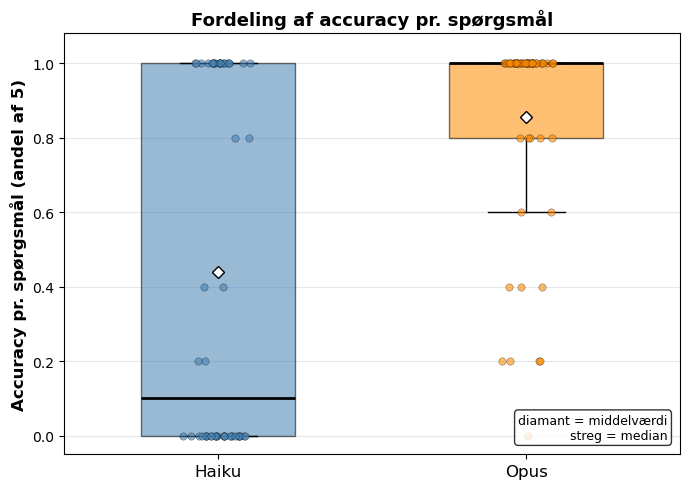

In [31]:
np.random.seed(0)
data = [df["Haiku_acc"], df["Opus_acc"]]; colors = ["steelblue","darkorange"]
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(data, patch_artist=True, widths=0.5, showmeans=True, showfliers=False,
                meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black"))
for patch, c in zip(bp["boxes"], colors): patch.set_facecolor(c); patch.set_alpha(0.55)
for med in bp["medians"]: med.set_color("black"); med.set_linewidth(2)
for i, (dd, c) in enumerate(zip(data, colors), start=1):
    ax.scatter(np.random.normal(i, 0.045, size=len(dd)), dd, color=c,
               alpha=0.6, edgecolor="black", linewidth=0.3, zorder=3, s=28)
ax.set_xticks([1, 2]); ax.set_xticklabels(["Haiku","Opus"], fontsize=12)
ax.set_ylabel("Accuracy pr. spørgsmål (andel af 5)", fontsize=12, fontweight="bold")
ax.set_title("Fordeling af accuracy pr. spørgsmål", fontsize=13, fontweight="bold")
ax.set_ylim(-0.05, 1.08); ax.grid(True, alpha=0.3, axis="y")
ax.text(0.98, 0.03, "diamant = middelværdi\nstreg = median", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=9, bbox=dict(boxstyle="round", fc="white", alpha=0.8))
plt.tight_layout(); plt.show()

## 10. Samlet resultatoversigt

In [30]:
print("=" * 64)
print("OPSUMMERING  (enhed: spørgsmål, n = 54)")
print("=" * 64)
print(f"Accuracy (flertalsafstemning):  Haiku {m_h}/54 = {m_h/n:.1%}   "
      f"Opus {m_o}/54 = {m_o/n:.1%}")
print(f"  Jeffrey 95% CI Haiku: [{ci_h[0]:.3f}, {ci_h[1]:.3f}]")
print(f"  Jeffrey 95% CI Opus:  [{ci_o[0]:.3f}, {ci_o[1]:.3f}]")
print("-" * 64)
print(f"McNemar (binært spor):   theta = {E:+.3f}  CI [{CI_mc[0]:.3f}, {CI_mc[1]:.3f}]  p = {p_mc:.2e}")
print(f"Wilcoxon (kontinuert):   median diff = {np.median(diff):+.3f}  r = {rbc:.3f}  p = {res.pvalue:.2e}")
print("-" * 64)
print("Begge tests peger samme vej: Opus signifikant bedre end Haiku.")
print("=" * 64)

OPSUMMERING  (enhed: spørgsmål, n = 54)
Accuracy (flertalsafstemning):  Haiku 23/54 = 42.6%   Opus 46/54 = 85.2%
  Jeffrey 95% CI Haiku: [0.301, 0.559]
  Jeffrey 95% CI Opus:  [0.740, 0.927]
----------------------------------------------------------------
McNemar (binært spor):   theta = +0.426  CI [0.271, 0.569]  p = 5.65e-06
Wilcoxon (kontinuert):   median diff = +0.400  r = 0.847  p = 6.40e-06
----------------------------------------------------------------
Begge tests peger samme vej: Opus signifikant bedre end Haiku.
